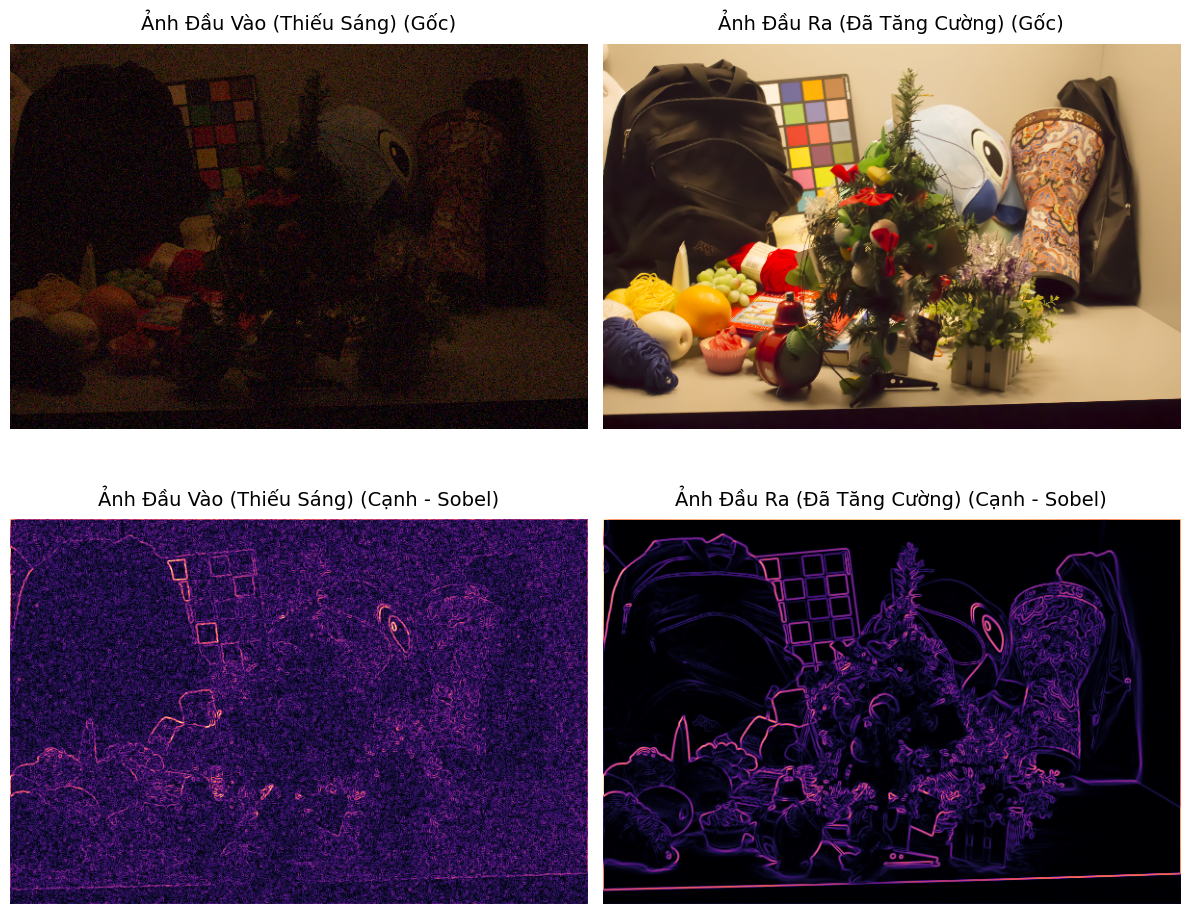

In [6]:
import torch
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import cv2
import numpy as np

def extract_edges_pytorch(img_tensor):
    """Hàm phụ trợ để trích xuất cạnh từ tensor ảnh sử dụng Sobel"""
    # Khai báo bộ lọc (Kernel) Sobel
    sobel_x = torch.tensor([[-1., 0., 1.], 
                            [-2., 0., 2.], 
                            [-1., 0., 1.]]).view(1, 1, 3, 3)
    sobel_y = torch.tensor([[-1., -2., -1.], 
                            [ 0.,  0.,  0.], 
                            [ 1.,  2.,  1.]]).view(1, 1, 3, 3)

    # Tính đạo hàm theo trục X và Y
    grad_x = F.conv2d(img_tensor, sobel_x, padding=1)
    grad_y = F.conv2d(img_tensor, sobel_y, padding=1)

    # Tính độ lớn (magnitude)
    gradient_magnitude = torch.sqrt(grad_x**2 + grad_y**2)
    
    # Chuẩn hóa về [0, 1]
    gradient_norm = gradient_magnitude / (gradient_magnitude.max() + 1e-8)
    return gradient_norm.squeeze().numpy()

def compare_two_images(img_path1, img_path2, title1="Ảnh 1", title2="Ảnh 2"):
    """
    So sánh cạnh của 2 bức ảnh
    """
    # 1. Load 2 ảnh màu (để hiển thị) và ảnh xám (để tính cạnh)
    try:
        # Đọc ảnh màu hiển thị
        img_rgb1 = cv2.cvtColor(cv2.imread(img_path1), cv2.COLOR_BGR2RGB)
        img_rgb2 = cv2.cvtColor(cv2.imread(img_path2), cv2.COLOR_BGR2RGB)
        
        # Đọc ảnh xám và chuyển sang Tensor
        transform = transforms.ToTensor()
        img_tensor1 = transform(Image.open(img_path1).convert('L')).unsqueeze(0)
        img_tensor2 = transform(Image.open(img_path2).convert('L')).unsqueeze(0)
    except Exception as e:
        print(f"Lỗi khi đọc ảnh, vui lòng kiểm tra lại đường dẫn: {e}")
        return

    # 2. Trích xuất cạnh
    edge1 = extract_edges_pytorch(img_tensor1)
    edge2 = extract_edges_pytorch(img_tensor2)

    # 3. Vẽ biểu đồ so sánh (Grid 2x2)
    plt.figure(figsize=(12, 10))
    
    # Hàng 1: Ảnh màu gốc
    plt.subplot(2, 2, 1)
    plt.title(f'{title1} (Gốc)', fontsize=14, pad=10)
    plt.imshow(img_rgb1)
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.title(f'{title2} (Gốc)', fontsize=14, pad=10)
    plt.imshow(img_rgb2)
    plt.axis('off')

    # Hàng 2: Bản đồ cạnh (Edges)
    plt.subplot(2, 2, 3)
    plt.title(f'{title1} (Cạnh - Sobel)', fontsize=14, pad=10)
    plt.imshow(edge1, cmap='magma') # Dùng cmap 'magma' hoặc 'gray' để nhìn rõ cạnh
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.title(f'{title2} (Cạnh - Sobel)', fontsize=14, pad=10)
    plt.imshow(edge2, cmap='magma')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# ==================== CÁCH SỬ DỤNG ====================
# Thay thế đường dẫn bằng ảnh thực tế của bạn
path_anh_thieu_sang = r"E:\PythonFile\Project\Low-Light-Image-Enhancement\mydata\dataset\dataset\LOLv2-real\Train\Input\00406.png"
path_anh_sang_ro = r"E:\PythonFile\Project\Low-Light-Image-Enhancement\mydata\dataset\dataset\LOLv2-real\Train\GT\00406.png"
compare_two_images(
    img_path1 = path_anh_thieu_sang, 
    img_path2 = path_anh_sang_ro,
    title1 = "Ảnh Đầu Vào (Thiếu Sáng)",
    title2 = "Ảnh Đầu Ra (Đã Tăng Cường)"
)